# 📝 Exercise M6.04

The aim of the exercise is to get familiar with the histogram
gradient-boosting in scikit-learn. Besides, we will use this model within a
cross-validation framework in order to inspect internal parameters found via
grid-search.

We will use the California housing dataset.

In [1]:
from sklearn.datasets import fetch_california_housing

data, target = fetch_california_housing(return_X_y=True, as_frame=True)
target *= 100  # rescale the target in k$

First, create a histogram gradient boosting regressor. You can set the trees
number to be large, and configure the model to use early-stopping.

In [2]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgbt = HistGradientBoostingRegressor(max_iter=10000, early_stopping=True)

We will use a grid-search to find some optimal parameter for this model. In
this grid-search, you should search for the following parameters:

* `max_depth: [3, 8]`;
* `max_leaf_nodes: [15, 31]`;
* `learning_rate: [0.1, 1]`.

Feel free to explore the space with additional values. Create the grid-search
providing the previous gradient boosting instance as the model.

In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 8],
    "max_leaf_nodes": [15, 31],
    "learning_rate": [0.1, 1]
}

gs_cv = GridSearchCV(
    hgbt,
    param_grid=param_grid,
    n_jobs=2
)

Finally, we will run our experiment through cross-validation. In this regard,
define a 5-fold cross-validation. Besides, be sure to shuffle the data.
Subsequently, use the function `sklearn.model_selection.cross_validate` to run
the cross-validation. You should also set `return_estimator=True`, so that we
can investigate the inner model trained via cross-validation.

In [4]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    gs_cv,
    data,
    target,
    cv=5,
    return_estimator=True
)

Now that we got the cross-validation results, print out the mean and standard
deviation score.

In [5]:
print(cv_results["test_score"].mean())
print(cv_results["test_score"].std())

0.6951322250242135
0.02218303227996814


Then inspect the `estimator` entry of the results and check the best
parameters values. Besides, check the number of trees used by the model.

In [6]:
for est in cv_results['estimator']:
    print(est.best_params_)
    print(est.best_estimator_.n_iter_)

{'learning_rate': 0.1, 'max_depth': 3, 'max_leaf_nodes': 31}
422
{'learning_rate': 0.1, 'max_depth': 3, 'max_leaf_nodes': 31}
613
{'learning_rate': 0.1, 'max_depth': 8, 'max_leaf_nodes': 31}
212
{'learning_rate': 0.1, 'max_depth': 8, 'max_leaf_nodes': 31}
255
{'learning_rate': 0.1, 'max_depth': 3, 'max_leaf_nodes': 15}
574


Inspect the results of the inner CV for each estimator of the outer CV.
Aggregate the mean test score for each parameter combination and make a box
plot of these scores.

In [7]:
import pandas as pd
import seaborn as sns

index_columns = [f"param_{name}" for name in param_grid.keys()]
columns = index_columns + ["mean_test_score"]

inner_cv_results = []
for est in cv_results['estimator']:
    search_cv_results = pd.DataFrame(est.cv_results_)
    search_cv_results = search_cv_results[columns].set_index(index_columns)
    inner_cv_results.append(search_cv_results)

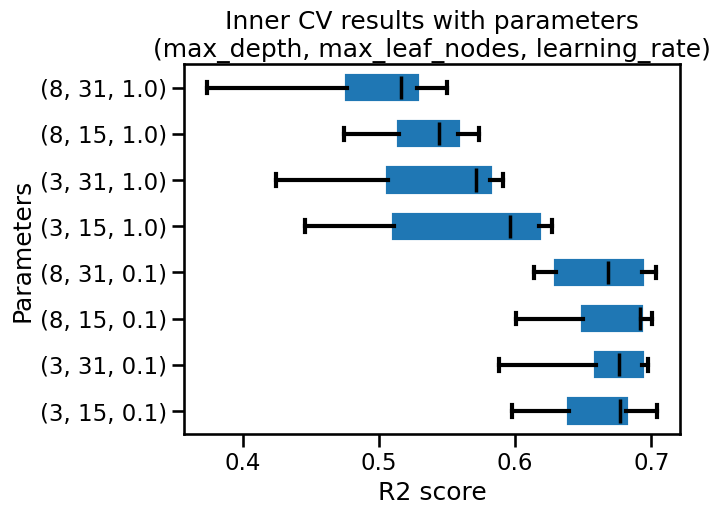

In [10]:
import matplotlib.pyplot as plt

color = {"whiskers": "black", "medians": "black", "caps": "black"}
inner_cv_results.plot.box(vert=False, color=color)
plt.xlabel("R2 score")
plt.ylabel("Parameters")
_ = plt.title(
    "Inner CV results with parameters\n"
    "(max_depth, max_leaf_nodes, learning_rate)"
)